# 04 · Calibrating HYPE

HYPE (SMHI) is a Fortran executable driven by a folder of text files, not an array function.
`HYPEModel` wraps it as a `BaseForwardModel`, so the engine, early stopping and
cross-validation all work unchanged.

Two things are different from every other model here:

- **The data goes in through `forcing=` and `observations()`, not through `X`.** HYPE reads
  precipitation and temperature from its own files, so you hand them over as DataFrames (or
  paths) and they are written into each worker folder before every run.
- **`X` carries dates.** Because the data arrives by that other route, there is nothing to
  put in a feature matrix: `X[:, 0]` holds the day ordinal of each sample and `forward`
  returns the simulated value for exactly those dates. One HYPE run covers the whole
  window and is cached, so slicing rows afterwards is free — which is what makes
  cross-validation and a held-out test block affordable here.

Two rules that follow:

- **Never put a scaler in front of it.** `Pipeline([StandardScaler(), GPURegressor(...)])`
  would transform the date column outside the estimator, where nothing can undo it.
- **Keep `shuffle=False`** (the default). Daily flows are strongly autocorrelated, so a
  shuffled split puts each held-out day between two training days and flatters the score.

In [ ]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt, numpy as np, pandas as pd
from sklearn.model_selection import KFold

from foresight_gpu import GPURegressor
from foresight_gpu.metrics.probabilistic import renard_metrics
from foresight_gpu.models.hype import (HYPEModel, as_X, autocalibrate, freeze,
                                       from_ordinals, load_observations, read_hype_table)
from foresight_gpu.utils import plot_double_pareto_front, plot_qq, plot_timeseries
%matplotlib widget

### Point this at your HYPE folder

The folder holding the executable and the `.txt` inputs. It is never written to — each
worker gets its own copy in a temp directory.

This notebook uses **Tomar**: a single-basin Portuguese catchment, so a run takes under a
second and a full cross-validation is a couple of minutes.

In [2]:
HYPE_FOLDER = Path(r'C:\Users\ruism\Desktop\Rui_local\03. Code\GPU+HYPE artigo\Tomar\HYPEFolder')
SUBBASIN = 9022                 # the outlet subbasin to read
EXECUTABLE = 'HYPEwithoutPopup4All.exe'
QOBS = HYPE_FOLDER.parent / 'Qobs_16G01H.txt'

print('folder exists:', HYPE_FOLDER.is_dir(), '| Qobs exists:', QOBS.is_file())
print('files:', sorted(p.name for p in HYPE_FOLDER.iterdir() if p.is_file())[:10])

folder exists: True | Qobs exists: True
files: ['Filedir.txt', 'GeoClass.txt', 'GeoData.txt', 'HYPE_5_23_0.exe', 'HYPEwithoutPopup4All.exe', 'HYPYwithoutPOPUP.exe', 'Pobs.txt', 'README.txt', 'Tobs.txt', 'hyss_000_260523_012749.9.log']


### Getting data in: three routes

`forcing=` accepts a mapping from a variable to **a DataFrame, a Series, or a path**. Keys
may be HYPE file names (`'Pobs.txt'`) or aliases (`'P'`, `'precipitation'`, `'T'`, `'tmin'`,
`'Qobs'`, …). Whatever you pass is written into every worker folder in HYPE's own format,
**replacing** what the template shipped with, and the matching `read*obs` switch is set in
`info.txt` for you.

| route | when to use it |
|---|---|
| `forcing={'P': df, 'T': df}` | the usual case — the data lives in Python, so you can perturb, bias-correct or swap it |
| `forcing={'P': path, 'T': path}` | the data is already in HYPE format on disk |
| *omit* `forcing` | fall back to the files already in the folder — fine for a fixed setup, but then the data is invisible to the caller |

All three are equivalent for the same underlying numbers; the difference is only where the
numbers come from. Below we read the folder's own files into DataFrames, so this notebook is
self-contained — substitute your own frames and nothing else changes.

In [3]:
# Replace these two with your own DataFrames: index = dates, one column per forcing id.
P = read_hype_table(HYPE_FOLDER / 'Pobs.txt')
T = read_hype_table(HYPE_FOLDER / 'Tobs.txt')

# Trim to the period to simulate; bdate/edate then follow the data.
PERIOD = slice('1979-02-01', '1999-12-31')
P, T = P.loc[PERIOD], T.loc[PERIOD]
forcing = {'P': P, 'T': T}

print(f'precipitation {P.shape} | temperature {T.shape}')
print(f'forcing ids : {list(P.columns)}')
print(f'period      : {P.index.min().date()} .. {P.index.max().date()}')
display(pd.concat({'P (mm/day)': P.describe().T, 'T (degC)': T.describe().T}).round(2))

precipitation (7639, 1) | temperature (7639, 1)
forcing ids : ['9022']
period      : 1979-02-01 .. 1999-12-31


,,count,mean,std,min,25%,50%,75%,max
P (mm/day),9022,7639.0,2.47,6.12,0.0,0.00,0.00,1.29,65.20
T (degC),9022,7639.0,15.55,5.10,1.7,11.58,15.04,19.47,31.62


### Build the model and see what it will actually calibrate

`parameters` names what you *want*; the model resolves that against `par.txt` and the
`modeloption` routines in force, then reports what survived. A parameter whose routine is
off, or that is commented out of `par.txt`, is dropped **with a warning** rather than
silently written into a file HYPE will ignore.

Note the window: `bdate` and `edate` follow the forcing, while `cdate` — the warmup
boundary — is kept from the template unless you override it. Supplying data does not throw
away the spin-up the template asked for.

In [4]:
PARAMETERS = ['wcfc', 'rrcs1', 'mperc1', 'mperc2', 'cmlt', 'preccorr', 'trrcs', 'macrate']

def make_model(**kw):
    """A fresh model; cross-validation needs one per fold."""
    options = dict(
        template_dir=HYPE_FOLDER,
        forcing=forcing,          # <- your data drives the model
        subbasin=SUBBASIN,
        executable=EXECUTABLE,
        parameters=PARAMETERS,
        cdate='1980-01-01',       # output/loss start here; bdate & edate follow the forcing
        n_workers=12,
        warn_unrequested=False,
    )
    options.update(kw)
    return HYPEModel(**options)

hype = make_model()
print('window           :', hype.simulation_window_, '(bdate/edate from the forcing)')
print('output steps     :', hype.output_window_[1])
print('forcing supplied :', sorted(hype.forcing_))
print('info.txt switches:', hype.forcing_switches_ or 'none needed')
print('active           :', hype.active_parameters_)
print('dropped          :', hype.dropped_parameters_ or 'none')
print('search dimensions:', hype.n_parameters(1))
hype.describe()

window           : ('1979-02-01', '1980-01-01', '1999-12-31') (bdate/edate from the forcing)
output steps     : 7305
forcing supplied : ['Pobs.txt', 'Tobs.txt']
info.txt switches: none needed
active           : ('wcfc', 'rrcs1', 'mperc1', 'mperc2', 'cmlt', 'preccorr', 'trrcs', 'macrate')
dropped          : none
search dimensions: 8


,label,parameter,mode,index,low,high,log
0,wcfc,wcfc,multiply,NaN,0.002666,5.988252,True
1,rrcs1,rrcs1,multiply,NaN,0.002397,9.296791,True
2,mperc1,mperc1,multiply,NaN,0.000004,3.743290,True
3,mperc2,mperc2,multiply,NaN,0.000004,3.743290,True
4,cmlt,cmlt,multiply,NaN,0.013868,28.200146,True
5,preccorr,preccorr,substitute,0.0,-1.000000,15.000000,False
6,trrcs,trrcs,multiply,NaN,0.002222,2.222222,True
7,macrate,macrate,multiply,NaN,0.005659,2.261778,True


### Toggling a routine changes the parameter set

`model_options` writes `modeloption` lines into each worker's `info.txt`, so switching a
routine needs no second copy of the HYPE folder.

Tomar is Mediterranean, so snow is irrelevant here — the interesting switch is
**`surfacerunoff`**, the fast overland-flow routine that matters during intense autumn
storms. It is *absent* from Tomar's `info.txt`, so `srrcs` and `srrate` are currently gated
off. Switching it on brings both into the search.

The cell below also shows the two **different** reasons a parameter gets excluded:
`srrcs`/`srrate` were excluded only because the routine was off, while `srbeta` stays
excluded either way — it is commented out of Tomar's `par.txt`, so HYPE would ignore it.

In [5]:
RUNOFF = ['srrcs', 'srrate', 'srbeta']

for options in ({}, {'surfacerunoff': 1}):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        probe = HYPEModel(template_dir=HYPE_FOLDER, forcing=forcing, subbasin=SUBBASIN,
                          executable=EXECUTABLE, parameters=RUNOFF,
                          model_options=options, warn_unrequested=False)
        try:
            state = probe.model_options_.get('surfacerunoff', 'absent')
            print(f"surfacerunoff={state}: {probe.n_parameters(1):>2} dims, "
                  f"active {probe.active_parameters_}")
            for name, why in probe.dropped_parameters_.items():
                print(f'    dropped {name:8s} {why}')
        except ValueError as exc:
            print(f"surfacerunoff=absent: nothing to calibrate - {exc}".split('.')[0])

surfacerunoff=absent: nothing to calibrate - No HYPE parameters left to calibrate
surfacerunoff=1:  6 dims, active ('srrcs', 'srrate')
    dropped srbeta   absent from par.txt (or commented out there) - HYPE would ignore it


### Observations, and holding out a test block *before* anything else

`observations()` reads the record and restricts it to the days the model can answer for, in
one call. Like `forcing=`, it takes **a DataFrame, a Series or a path** — and the same is
true of the lower-level `load_observations`.

Gaps are normal in a discharge record and are dropped here, because `GPURegressor.fit`
cannot take NaN in `y` (scikit-learn validates the target strictly). Dropping is safe
precisely because the date travels with the row.

Then the split. **The test block is carved out first and never touched again** — not by
cross-validation, not by model selection. Everything before `TEST_START` is the pool the
folds share; everything after is the honest verdict.

```
|<------------- train pool ------------->|<---- TEST: untouched ---->|
|  fold 1  |  fold 2  |  fold 3  |                                  |
```

In [6]:
TEST_START = '1995-01-01'      # <- edit: everything from here is held out

X, y = hype.observations(QOBS, column=str(SUBBASIN))
dates = pd.DatetimeIndex(from_ordinals(X[:, 0]))

is_test = dates >= TEST_START
X_pool, y_pool = X[~is_test], y[~is_test]
X_test, y_test = X[is_test], y[is_test]
dates_test = dates[is_test]

print(f'usable days : {X.shape[0]} of {hype.output_window_[1]} in the window')
print(f'train pool  : {X_pool.shape[0]:>5} days  {dates[~is_test].min().date()} .. '
      f'{dates[~is_test].max().date()}')
print(f'test block  : {X_test.shape[0]:>5} days  {dates_test.min().date()} .. '
      f'{dates_test.max().date()}')

# the same observations, three ways in - the routes are interchangeable
alt = hype.observations(read_hype_table(QOBS), column=str(SUBBASIN))
assert np.array_equal(alt[0], X) and np.array_equal(alt[1], y)
print('\npath and DataFrame routes agree:', True)

usable days : 7058 of 7305 in the window
train pool  :  5232 days  1980-01-01 .. 1994-12-31
test block  :  1826 days  1995-01-01 .. 1999-12-31

path and DataFrame routes agree: True


### Budget the run before starting it

Every generation runs one HYPE simulation per particle, so the cost is predictable — and
cross-validation multiplies it:

| stage | runs |
|---|---|
| screening (`screen=True`) | `screen_oversample × population` |
| each generation | `population` |
| each early-stopping check | 0 — served from the cache |
| **each extra CV fold** | **the whole fit again** |
| scoring a fitted model on *any* window | 0 — the cache again |

The last two lines are the whole story of this notebook. A fold costs a full calibration
because each fold `clone`s the model and gets its own workspace and cache — k parameter
estimates is the point, and nothing can make that cheaper. But **evaluating** any of those
models on the test block is free, because the whole window is already simulated.

`screen=True` earns its keep beyond the usual: it spreads the initial swarm across the
exceedance axis, which speeds convergence *and* shrinks the window in which a failed run
could reach the front.

**Do not cut the budget below this.** Tomar's search box spans about four decades - the low
corner simulates 0 m3/s everywhere and the high corner around 445, against an observed mean
of 7.3 - so the swarm needs room to find the region at all. Measured on this catchment,
holding everything else fixed:

| population x generations | runs per fit | ~min per fit | alpha | xi | scored | pi |
|---|---|---|---|---|---|---|
| 24 x 8 | 240 | 1.1 | 0.23 | 0.03 | 0.79 | `inf` |
| **40 x 15** | **720** | **3.3** | **0.75** | **0.86** | **1.00** | **0.76** |
| 60 x 25 | 1680 | 7.5 | 0.97 | 0.91 | 1.00 | 0.73 |

The first row is not just *worse*, it is quietly broken: every band collapses onto the same
value, so the sharpness `pi = 1/std` becomes infinite and a fifth of the observations get no
p-value at all. Nothing raises. That is why the fold table below reports `scored` and why
`failed` is checked per fold.

The middle row is what this notebook uses - enough to be meaningful in a few minutes. The
last row shows the budget still buys reliability well past that (`alpha` 0.75 to 0.97), so
treat 40 x 15 as a floor for anything you intend to believe, not a recommendation.

In [7]:
POPULATION, N_ITER, OVERSAMPLE, K_FOLDS = 40, 15, 3, 3

# Modest quantiles with a wider band: with 40 members the 16 default bands would leave
# some empty, and an empty band is silently dropped rather than flagged.
QUANTILES = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
FIT = dict(metric='mae', population=POPULATION, n_iter=N_ITER,
           screen=True, screen_oversample=OVERSAMPLE,
           quantiles=QUANTILES, band_width=0.05,
           force_positive=True, random_state=0)

per_fit = (OVERSAMPLE + N_ITER) * POPULATION
total = (K_FOLDS + 1) * per_fit          # k folds, plus the final refit
print(f'{per_fit} runs per fit x ({K_FOLDS} folds + 1 final) = {total} HYPE runs')
for seconds in (0.75, 2, 10):
    print(f'  at {seconds:>5.2f}s per run over {hype.n_workers} workers: '
          f'{total * seconds / hype.n_workers / 60:5.1f} min')

720 runs per fit x (3 folds + 1 final) = 2880 HYPE runs
  at  0.75s per run over 12 workers:   3.0 min
  at  2.00s per run over 12 workers:   8.0 min
  at 10.00s per run over 12 workers:  40.0 min


### Cross-validate on contiguous blocks

`KFold(n_splits=k, shuffle=False)` cuts the pool into k **consecutive** blocks. Each is
held out once while the model trains on the other k−1, so every part of the record gets
tested — unlike `TimeSeriesSplit`, where the earliest years never are, and every fold trains
on ~(k−1)/k of the pool rather than a growing prefix.

Two numbers come out of each fold, and the gap between them is the interesting part:

- **α on the fold's own block** — the classic CV score. Contiguous blocks still *touch*:
  the day before a held-out block is a training day, and recession memory spans days to
  weeks, so this is mildly optimistic. `KFold` has no `gap=`.
- **α on the untouched test block** — the honest number, and the reason the test block was
  carved out first.

Note this measures *record-wide consistency* — whether the calibration is stable across the
record. It is not forecast skill; for that you want `TimeSeriesSplit`, which never trains on
the future. Different question.

We loop manually rather than using `cross_val_score`, because we want each fold's run
counts and its ensemble — and because each fold's workspace must be closed, or every clone
leaves a temp folder and eight HYPE processes behind.

In [8]:
def diagnose(gpu, X_eval, y_eval):
    """Renard diagnostics, plus how many observations the ensemble could actually score."""
    bands = gpu.predict_quantiles(X_eval)
    pv = gpu.predictive_pvalues(X_eval, y_eval)
    d = renard_metrics(pv, bands, gpu.ensemble_.band_probabilities)
    # pi = 1/std is infinite if any day's bands collapse to a single value, which is what a
    # swarm that never spread looks like. Keep it comparable and flag it instead.
    d = {k: (np.nan if not np.isfinite(v) else float(v)) for k, v in d.items()}
    d['scored'] = int(np.isfinite(pv).sum()) / len(pv)
    return d, bands, pv

rows, fold_models, fold_preds = [], [], {}
for fold, (train_idx, block_idx) in enumerate(
        KFold(n_splits=K_FOLDS, shuffle=False).split(X_pool), start=1):
    model = make_model()
    gpu = GPURegressor(model=model, **FIT).fit(X_pool[train_idx], y_pool[train_idx])
    inner = gpu.model_

    own, _, _ = diagnose(gpu, X_pool[block_idx], y_pool[block_idx])   # own block
    test, bands_test, pv_test = diagnose(gpu, X_test, y_test)         # untouched block
    # Keep the arrays, not the model: plotting later then costs no HYPE runs and does not
    # depend on the fold's workspace still being alive.
    fold_preds[fold] = {'bands': bands_test, 'pvalues': pv_test,
                        'alpha': test['alpha'], 'scored': test['scored']}
    rows.append({
        'fold': fold, 'train days': len(train_idx), 'block days': len(block_idx),
        'runs': inner.n_runs_, 'failed': inner.n_failed_runs_,
        'alpha (own block)': own['alpha'], 'alpha (test)': test['alpha'],
        'xi (test)': test['xi'], 'pi (test)': test['pi'], 'scored (test)': test['scored'],
    })
    fold_models.append((gpu, inner))
    print(f"fold {fold}: {inner.n_runs_} runs, {inner.n_failed_runs_} failed, "
          f"alpha own={own['alpha']:.3f} test={test['alpha']:.3f}")

cv = pd.DataFrame(rows).set_index('fold')
display(cv.round(3))
print(f'total HYPE runs across folds: {cv["runs"].sum()} (predicted {K_FOLDS * per_fit})')
print(f'alpha on the test block: {cv["alpha (test)"].mean():.3f} '
      f'+/- {cv["alpha (test)"].std():.3f} across folds')

fold 1: 720 runs, 0 failed, alpha own=0.929 test=0.930
fold 2: 720 runs, 0 failed, alpha own=0.848 test=0.911
fold 3: 720 runs, 0 failed, alpha own=0.859 test=0.887


,train days,block days,runs,failed,alpha (own block),alpha (test),xi (test),pi (test),scored (test)
fold,,,,,,,,,
1,3488,1744,720,0,0.929,0.930,0.841,0.680,1.0
2,3488,1744,720,0,0.848,0.911,0.843,0.648,1.0
3,3488,1744,720,0,0.859,0.887,0.854,0.675,1.0


total HYPE runs across folds: 2160 (predicted 2160)
alpha on the test block: 0.910 +/- 0.022 across folds


Two things to read off that table.

**`failed` must be 0.** A failed run returns NaN, which scores non-exceedance *exactly* 0.0
— and because the double-Pareto sorter ranks by exceedance *coverage* rather than by loss,
a failure can be mistaken for a precious tail model while the population is still narrow.
k folds means k independent chances for a broken template to show up.

**`scored (test)` should be close to 1.** It is the fraction of test observations the
ensemble could actually place. A fold whose swarm failed to spread across the exceedance
axis leaves bands empty, those observations get no p-value, and α is then computed from
whatever is left — a small number that looks just like a large one. If this drops, raise
`population` or widen `band_width` before trusting the α column.

In [9]:
# Fold models have served their purpose; release their workspaces and worker processes.
for gpu, inner in fold_models:
    inner.close()
fold_models.clear()
print('fold workspaces released')

fold workspaces released


### Each fold, side by side on the same test block

The pairing from `00_quickstart` — predictive bands next to the predictive QQ — but one row
per fold. Every panel is the **same** held-out period, so the rows are directly comparable:
this is the k calibrations disagreeing (or not) about the same five years.

Read the QQ column first. A curve hugging the diagonal means that fold's bands are
*reliable* — an observation falls below the 10 % band about a tenth of the time. A curve
bowing above the diagonal means the bands sit too high, below it too low, and an S-shape
means they are the wrong width rather than in the wrong place.

Costs nothing: the arrays were kept from the fold loop, where scoring the test block was
already free.

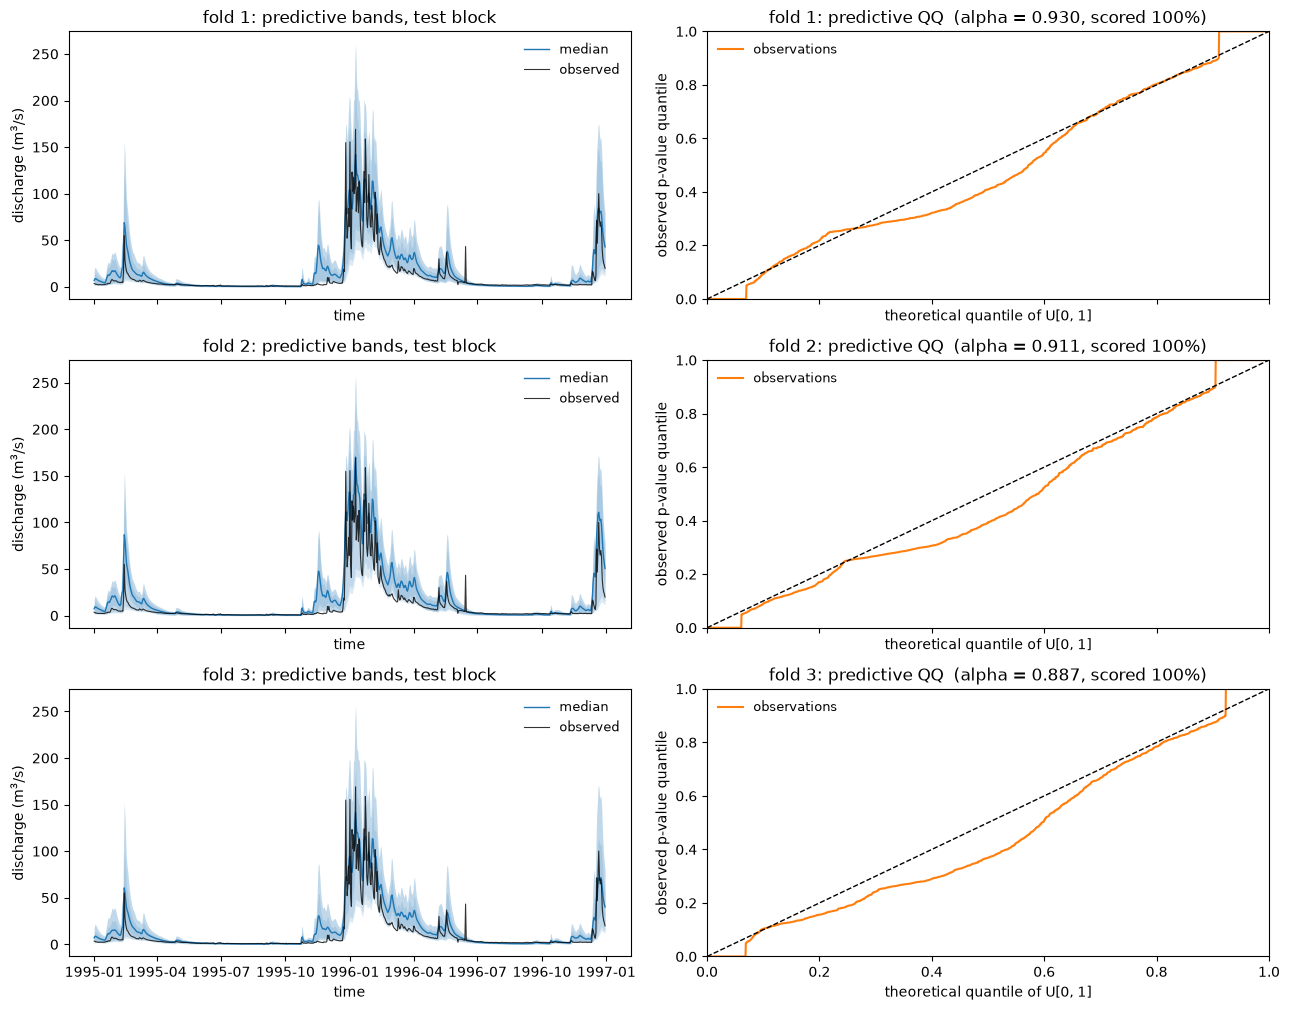

In [10]:
n_rows = len(fold_preds)
fig, axes = plt.subplots(n_rows, 2, figsize=(13, 3.4 * n_rows),
                         squeeze=False, sharex='col', sharey='col')
window = slice(0, 730)          # first two test years, so the hydrograph stays readable

for row, (fold, pred) in enumerate(sorted(fold_preds.items())):
    plot_timeseries(pred['bands'][window], QUANTILES, observed=y_test[window],
                    index=dates_test[window], ax=axes[row, 0])
    axes[row, 0].set_title(f"fold {fold}: predictive bands, test block")
    axes[row, 0].set_ylabel('discharge (m$^3$/s)')
    plot_qq(pred['pvalues'], ax=axes[row, 1])
    # `scored` in the title too: an empty-banded fold would otherwise show a bare `nan`
    # with nothing to say why.
    axes[row, 1].set_title(f"fold {fold}: predictive QQ  "
                           f"(alpha = {pred['alpha']:.3f}, scored {pred['scored']:.0%})")

fig.tight_layout()

### The model you keep

Cross-validation measured how stable the calibration is; it does not hand you a model. So
refit once on the **whole** train pool — more data than any single fold saw — and use the
test block, still untouched, for the bands and the diagnostics.

In [ ]:
final_model = make_model()
gpu = GPURegressor(model=final_model, **FIT).fit(X_pool, y_pool)
inner = gpu.model_

print(f'generations run : {gpu.n_iter_}')
print(f'HYPE runs       : {inner.n_runs_} (predicted {per_fit})')
print(f'cache hits      : {inner.n_cache_hits_}')
print(f'failed runs     : {inner.n_failed_runs_}')
print(f'front members   : {gpu.ensemble_.n_models}')
print(f'exceedance span : {gpu.ensemble_.exceedances.min():.3f} .. '
      f'{gpu.ensemble_.exceedances.max():.3f}')

In [ ]:
before = inner.n_runs_
bands = gpu.predict_quantiles(X_test)
pvalues = gpu.predictive_pvalues(X_test, y_test)
print('extra HYPE runs to evaluate the whole test block:', inner.n_runs_ - before)

diagnostics = renard_metrics(pvalues, bands, gpu.ensemble_.band_probabilities)
print({k: round(float(v), 3) for k, v in diagnostics.items()})
print('bands populated:', int((~np.isnan(bands).all(axis=0)).sum()), 'of', bands.shape[1])

In [ ]:
window = slice(0, 730)          # the first two test years

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
plot_timeseries(bands[window], QUANTILES, observed=y_test[window],
                index=dates_test[window], ax=axes[0])
axes[0].set_title('Predictive bands, test block')
axes[0].set_ylabel('discharge (m$^3$/s)')
plot_qq(pvalues, ax=axes[1])
axes[1].set_title('Predictive QQ (out-of-sample)')
plot_double_pareto_front(gpu._fit[:, 0], gpu._fit[:, 1], ax=axes[2], max_fronts=6)
axes[2].set_title('Exceedance vs loss')
fig.tight_layout()

### What the front says about the parameters

The retained members are stored as **physical** values, directly writable to a `par.txt`.
Their spread is the range of parameter sets consistent with the observations at different
exceedance levels — it is *not* a confidence interval on a single best set.

In [ ]:
table = inner.describe(gpu.ensemble_.params)
display(table[['label', 'parameter', 'mode', 'low', 'p10', 'median', 'p90', 'high']].round(5))

# Hand the median-exceedance member back to HYPE as a plain par.txt.
central = int(np.argmin(np.abs(gpu.ensemble_.exceedances - 0.5)))
inner.write_par('par_calibrated.txt', gpu.ensemble_.params[central])
print('wrote par_calibrated.txt from the member at exceedance '
      f'{gpu.ensemble_.exceedances[central]:.3f}')

### Freeze it for later, without HYPE

A fitted `HYPEModel` keeps only the *path* to its template, so an unpickled estimator can
predict only where that folder exists and HYPE runs. `freeze` collapses the retained front
into one pre-simulated table: same bands, no executable, no template, prediction by index
lookup. This is the artifact to keep for evaluation or hand to an operational system.

In [ ]:
import pickle

frozen = freeze(gpu.ensemble_)
np.testing.assert_allclose(frozen.predict_quantiles(X_test), bands, equal_nan=True)

Path('hype_frozen.pkl').write_bytes(pickle.dumps(frozen))
print('identical predictions, pickle is',
      round(Path('hype_frozen.pkl').stat().st_size / 1e6, 2), 'MB and needs no HYPE')

### The benchmark: HYPE's own DE-MC calibration

`autocalibrate` derives `optpar.txt` from the *same* parameter catalogue, switches
`calibration y` on and parses `respar.txt` back, so the obvious comparison needs no
hand-editing. It optimises a single weighted criterion and returns one best set, where GPU
returns a population spread across the exceedance axis — the two answer different questions.

It needs `Qobs.txt` **inside** the HYPE folder (the GPU route takes observations from `y`
instead) and runs `DEMC_ngen × DEMC_npop` simulations in one process, so keep both small.

In [ ]:
if (HYPE_FOLDER / 'Qobs.txt').exists():
    result = autocalibrate(hype, criteria=[('MR2', 'cout', 'rout', 1.0)],
                           ngen=6, npop=8, verbose=1)
    display(result.to_frame().round(5))
else:
    print('HYPE reads observations from Qobs.txt inside the model folder for its own')
    print(f'calibration; {HYPE_FOLDER.name} has none, so this step is skipped.')
    print("Copy the record in as Qobs.txt (column named for the SUBID) to enable it.")

### Tidy up

Worker folders live in a system temp directory and are removed on `close()` (and at
interpreter exit). Point `work_root` at a fast local disk if your temp drive is slow — and
never at a cloud-synced folder, since thousands of runs each write output.

In [ ]:
inner.close()
final_model.close()
hype.close()
print('done')

### Reading the result

The QQ plot is the verdict: a curve close to the diagonal means the bands are *reliable* —
an observation falls below the 10 % band about a tenth of the time. Renard's `alpha`
summarises that, `pi` measures sharpness, and the two trade off, which is why the objective
space in the third panel is a front rather than a point.

Three habits worth keeping:

- **Compare the folds with the final refit.** The folds trained on ~2/3 of the pool and the
  final model on all of it, so the final score should be at least as good. When it is not -
  and on this run it was not - the limiting factor is the *budget*, not the data: MOPSO is
  stochastic, and at 15 generations the run-to-run spread is comparable to what extra data
  buys. The 60 x 25 row in the budget table is the fix.
- **Read the CV spread as a lower bound.** All folds share `random_state=0`, so they start
  from the same screened swarm; genuine run-to-run variance is wider than the +/- you see.
- **Watch `failed` and `scored`.** A NaN run scores non-exceedance exactly 0.0 and can be
  mistaken for a tail model; an unpopulated band silently removes observations from the
  score. `max_failure_fraction` aborts a systematically broken setup, but a handful of
  failures only warns.
- **Budget before you start.** The run table is the whole cost model: `population`,
  `n_iter` and the number of folds are the only real levers, and a wrong `executable` path
  can otherwise burn an hour producing a plausible-looking fit over nothing.

Next: `03_diagnostics.ipynb` for early stopping and `GridSearchCV`, both of which work here
unchanged — and with the cache an early-stopping check costs no HYPE runs at all.